Loading data...
Shape: (375734, 251)



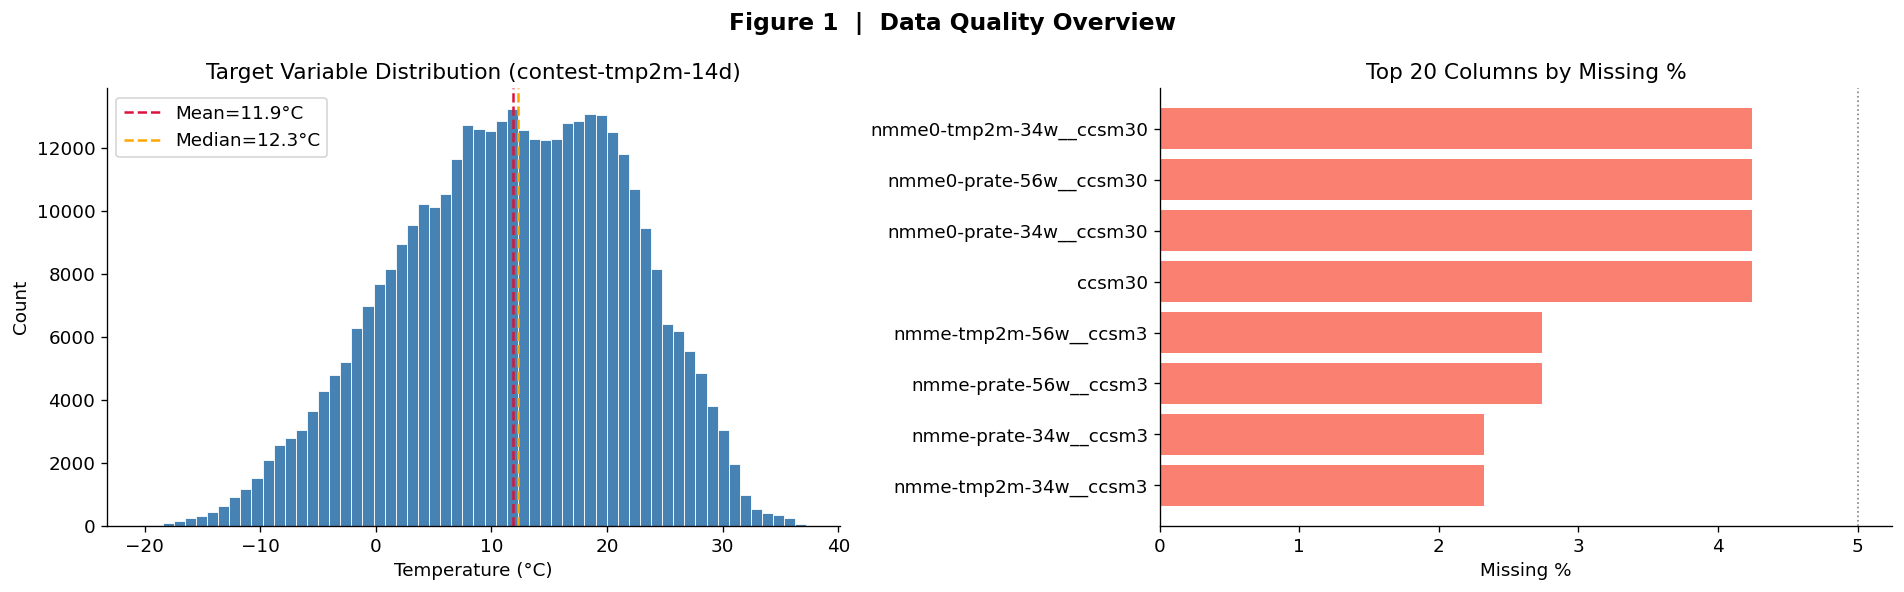

[1/4] Saved: outputs/figures/fig1_data_quality.png



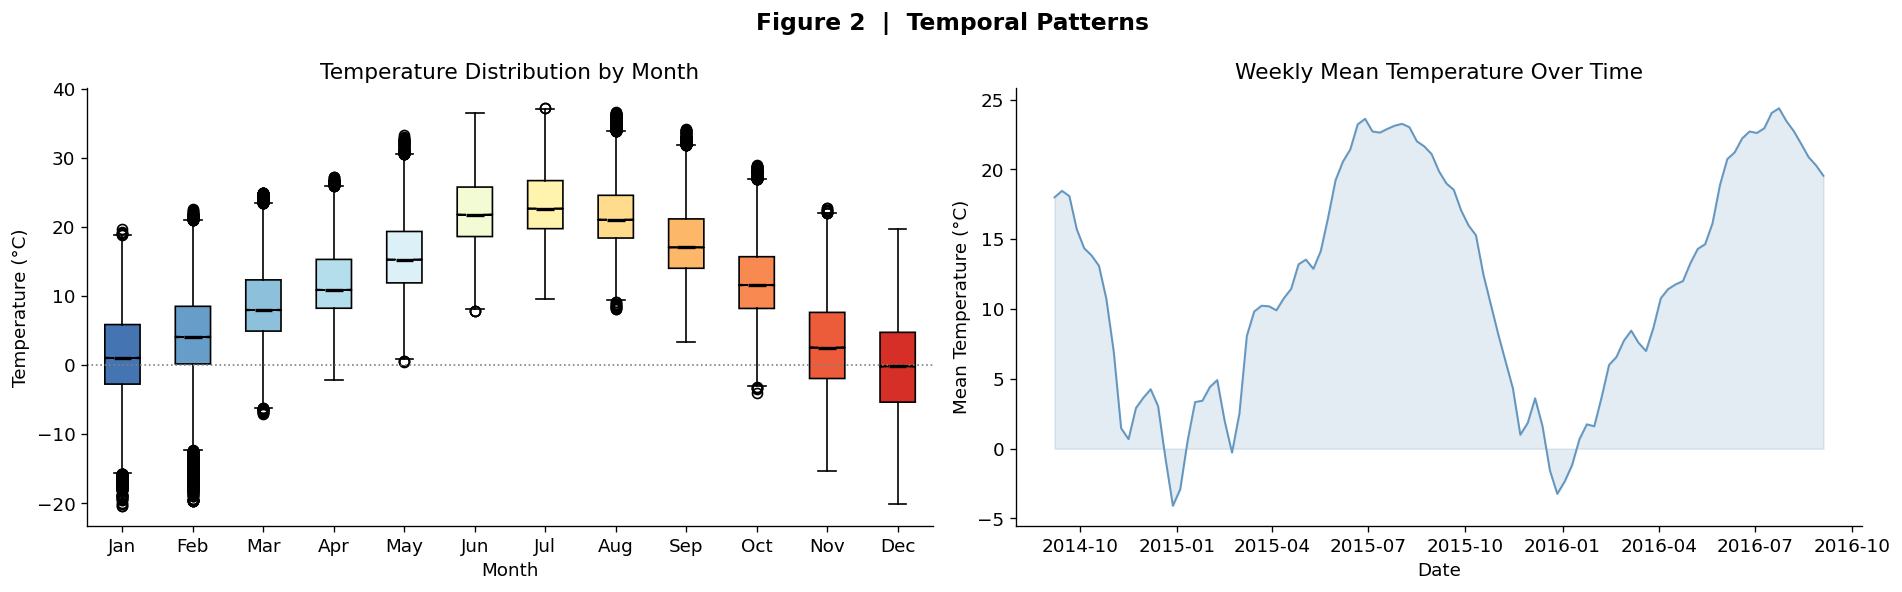

[2/4] Saved: outputs/figures/fig2_temporal.png



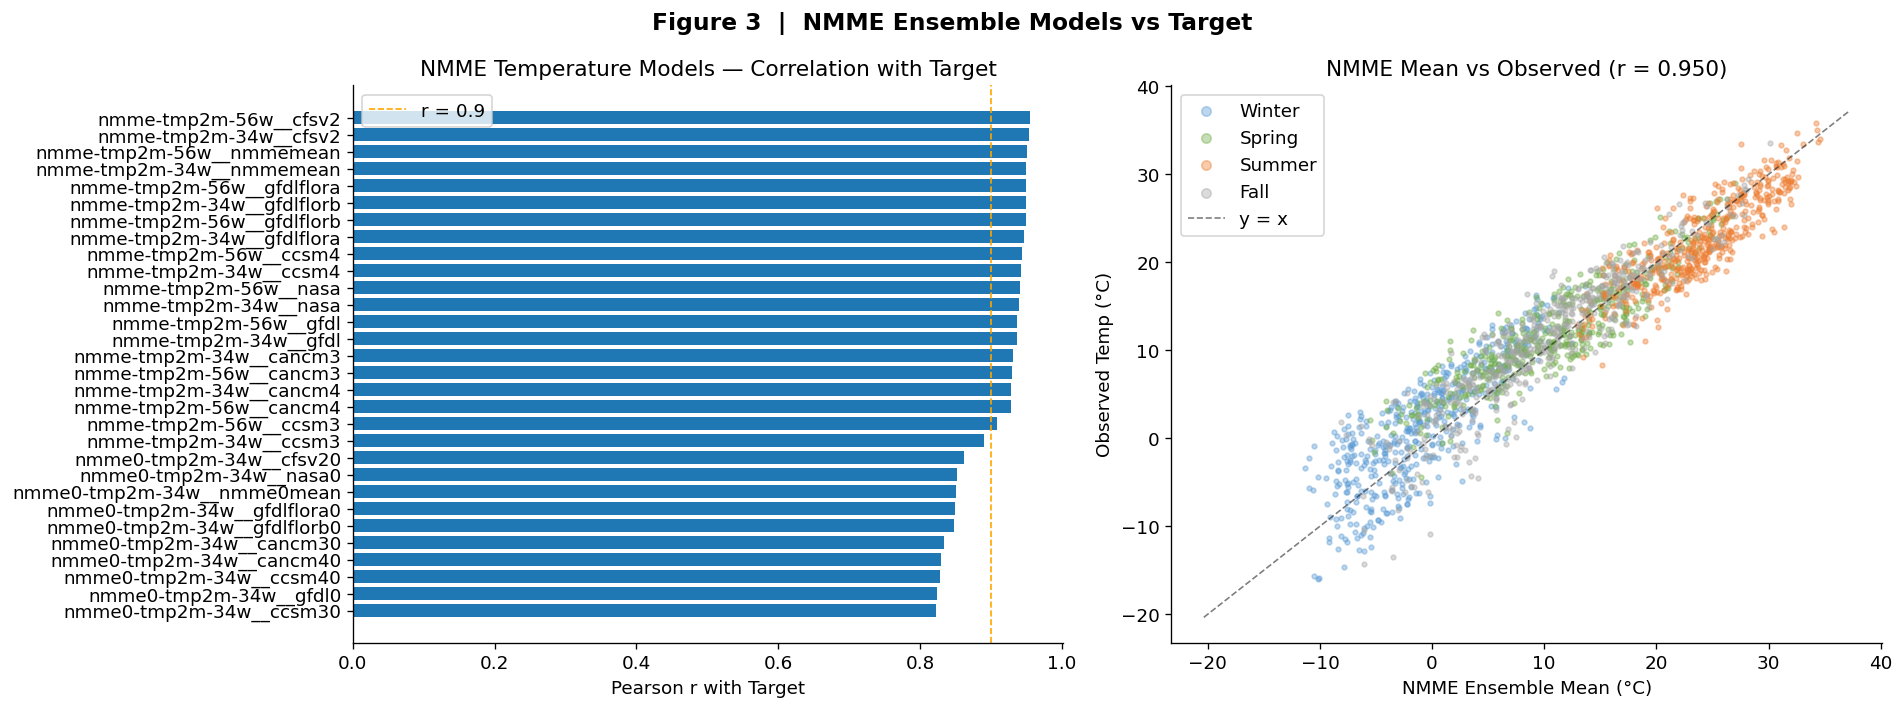

[3/4] Saved: outputs/figures/fig3_nmme.png


Running feature selection models (this may take ~1-2 min)...
    n_features=  5  RMSE=2.887
    n_features= 10  RMSE=2.861
    n_features= 15  RMSE=2.974
    n_features= 20  RMSE=2.933
    n_features= 30  RMSE=2.982
    n_features= 50  RMSE=2.955
    n_features= 80  RMSE=2.892
    n_features=242  RMSE=2.856


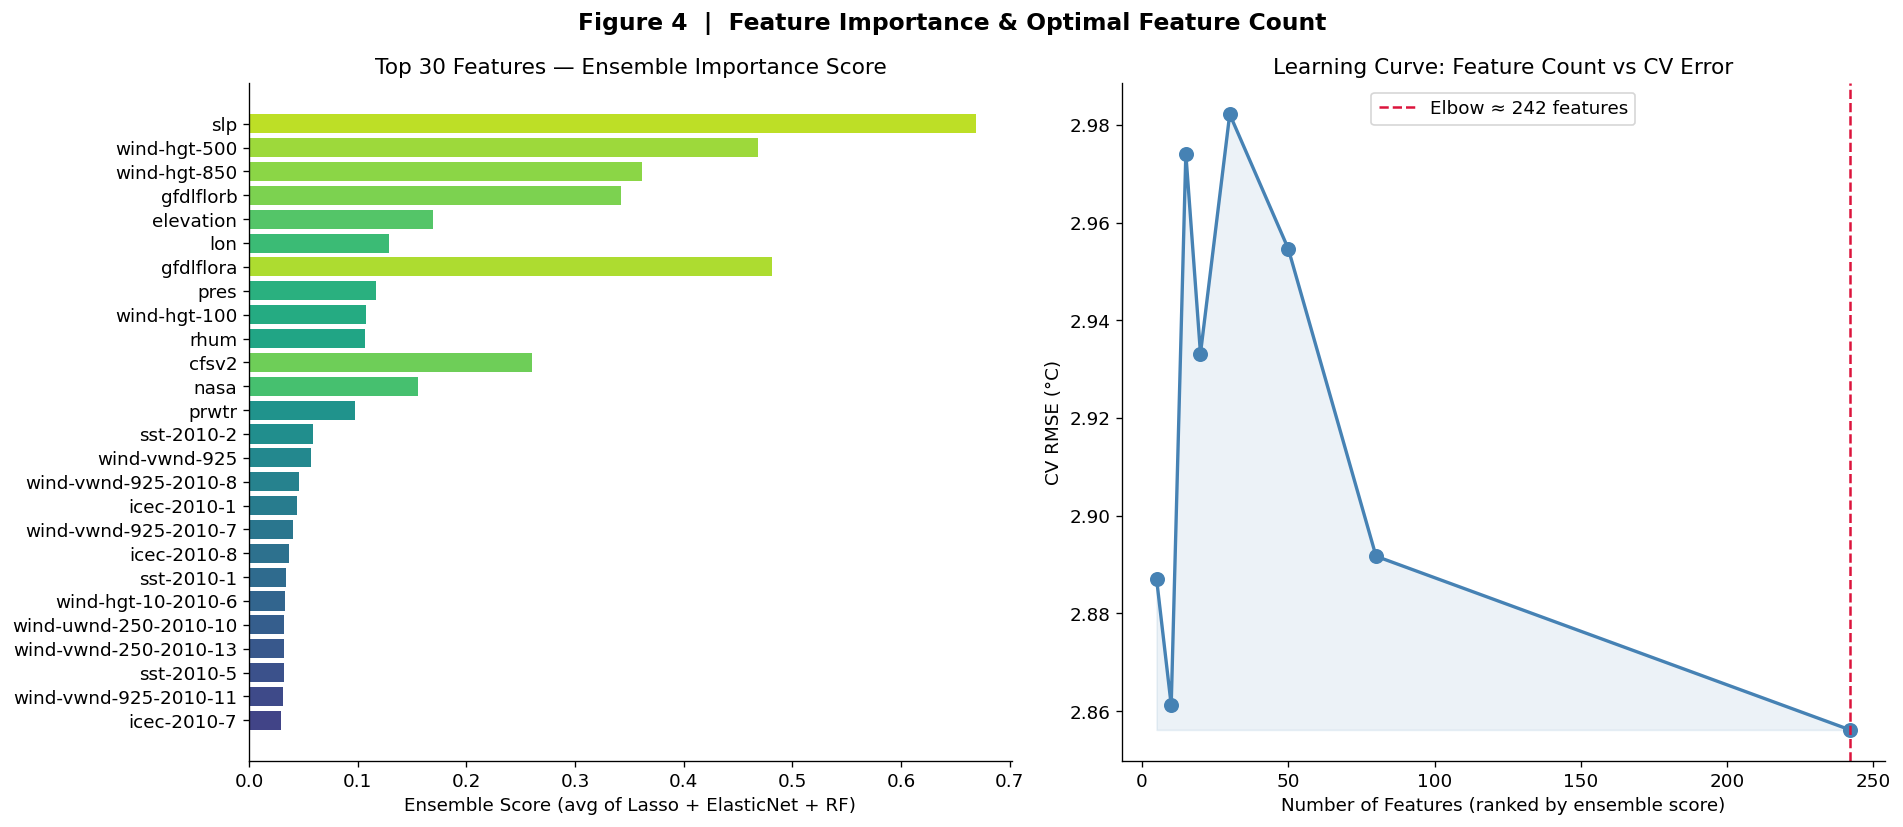

[4/4] Saved: outputs/figures/fig4_feature_importance.png


EDA SUMMARY
Target mean: 11.86°C  |  std: 9.87°C
Date range: 2014-09-01 to 2016-08-31

Top 5 features by ensemble score:
  contest-slp-14d__slp                               score=0.668
  nmme-tmp2m-56w__gfdlflora                          score=0.481
  contest-wind-h500-14d__wind-hgt-500                score=0.469
  contest-wind-h850-14d__wind-hgt-850                score=0.362
  nmme-tmp2m-34w__gfdlflorb                          score=0.342

Optimal feature count (elbow): ~242
Missing value columns (before cleaning): 0


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

"""
EDA for Weather Temperature Prediction Dataset
目标变量: contest-tmp2m-14d__tmp2m (未来14天2米气温)
4 张图 × 2 子图: 数据质量 → 时间规律 → NMME预测力 → 特征筛选
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from config import DATA_RAW, TARGET, SEASON_ORDER, SEASON_PALETTE, FIG_DIR
from src.preprocessing import load_and_clean, get_column_groups, build_feature_matrix
from src.feature_engineering import compute_ensemble_importance
from src.evaluate import feature_count_curve

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ─── 0. 加载 & 预处理 ────────────────────────────────────────
print("Loading data...")
df_raw = pd.read_csv(DATA_RAW)
miss_pct = df_raw.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False).head(20)

df = load_and_clean(DATA_RAW)
col_groups = get_column_groups(df)
nmme_tmp_cols = col_groups['nmme_tmp']
print(f"Shape: {df.shape}\n")
del df_raw


# ════════════════════════════════════════════════════════════════
# Figure 1 | 数据质量概览: 目标分布 + 缺失值
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Figure 1  |  Data Quality Overview", fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(df[TARGET].dropna(), bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(df[TARGET].mean(), color='crimson', linestyle='--', label=f'Mean={df[TARGET].mean():.1f}°C')
ax.axvline(df[TARGET].median(), color='orange', linestyle='--', label=f'Median={df[TARGET].median():.1f}°C')
ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('Count')
ax.set_title('Target Variable Distribution (contest-tmp2m-14d)')
ax.legend()

ax = axes[1]
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1], color='salmon')
ax.set_xlabel('Missing %'); ax.set_title('Top 20 Columns by Missing %')
ax.axvline(5, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_data_quality.png', bbox_inches='tight')
plt.show()
print("[1/4] Saved: outputs/figures/fig1_data_quality.png\n")


# ════════════════════════════════════════════════════════════════
# Figure 2 | 时间模式: 月份箱线图 + 周均时间序列
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Figure 2  |  Temporal Patterns", fontsize=14, fontweight='bold')

ax = axes[0]
data_by_month = [df[df['month'] == m][TARGET].dropna() for m in range(1, 13)]
bp = ax.boxplot(data_by_month, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 12))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Month'); ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Distribution by Month')
ax.axhline(0, color='gray', linestyle=':', linewidth=1)

ax = axes[1]
ts = df.groupby('startdate')[TARGET].mean().sort_index()
ts_weekly = ts.resample('W').mean()
ax.plot(ts_weekly.index, ts_weekly.values, color='steelblue', linewidth=1.2, alpha=0.8)
ax.fill_between(ts_weekly.index, ts_weekly.values, alpha=0.15, color='steelblue')
ax.set_xlabel('Date'); ax.set_ylabel('Mean Temperature (°C)')
ax.set_title('Weekly Mean Temperature Over Time')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_temporal.png', bbox_inches='tight')
plt.show()
print("[2/4] Saved: outputs/figures/fig2_temporal.png\n")


# ════════════════════════════════════════════════════════════════
# Figure 3 | NMME 预测力: 相关系数 + 散点图
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 3  |  NMME Ensemble Models vs Target", fontsize=14, fontweight='bold')

ax = axes[0]
corr_nmme = df[nmme_tmp_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colors_bar = ['#d62728' if v < 0 else '#1f77b4' for v in corr_nmme.values]
ax.barh(corr_nmme.index, corr_nmme.values, color=colors_bar)
ax.set_xlabel("Pearson r with Target")
ax.set_title('NMME Temperature Models — Correlation with Target')
ax.axvline(0.9, color='orange', linestyle='--', linewidth=1, label='r = 0.9')
ax.legend()

ax = axes[1]
nmme_mean_col = 'nmme-tmp2m-34w__nmmemean'
for season in SEASON_ORDER:
    sub = df[df['season'] == season].sample(
        min(500, len(df[df['season'] == season])), random_state=42)
    ax.scatter(sub[nmme_mean_col], sub[TARGET], alpha=0.4, s=8,
               color=SEASON_PALETTE[season], label=season)
lims = [min(df[nmme_mean_col].min(), df[TARGET].min()),
        max(df[nmme_mean_col].max(), df[TARGET].max())]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='y = x')
r = df[[nmme_mean_col, TARGET]].corr().iloc[0, 1]
ax.set_xlabel('NMME Ensemble Mean (°C)'); ax.set_ylabel('Observed Temp (°C)')
ax.set_title(f'NMME Mean vs Observed (r = {r:.3f})')
ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_nmme.png', bbox_inches='tight')
plt.show()
print("[3/4] Saved: outputs/figures/fig3_nmme.png\n")


# ════════════════════════════════════════════════════════════════
# Figure 4 | 特征重要性: 集成得分 + 学习曲线
# ════════════════════════════════════════════════════════════════
print("\nRunning feature selection models (this may take ~1-2 min)...")
X, y, feature_cols = build_feature_matrix(df, TARGET)
ensemble_score = compute_ensemble_importance(X, y)
top30 = ensemble_score.head(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Figure 4  |  Feature Importance & Optimal Feature Count",
             fontsize=14, fontweight='bold')

ax = axes[0]
top30_sorted = top30.sort_values(ascending=True)
short_labels = [f.split('__')[-1][:30] for f in top30_sorted.index]
ax.barh(short_labels, top30_sorted.values,
        color=plt.cm.viridis(np.linspace(0.2, 0.9, 30)))
ax.set_xlabel('Ensemble Score (avg of Lasso + ElasticNet + RF)')
ax.set_title('Top 30 Features — Ensemble Importance Score')

ax = axes[1]
feat_counts, cv_rmses = feature_count_curve(X, y, ensemble_score)
ax.plot(feat_counts, cv_rmses, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.fill_between(feat_counts, cv_rmses, min(cv_rmses), alpha=0.1, color='steelblue')
best_n = feat_counts[np.argmin(cv_rmses)]
ax.axvline(best_n, color='crimson', linestyle='--', label=f'Elbow ≈ {best_n} features')
ax.set_xlabel('Number of Features (ranked by ensemble score)')
ax.set_ylabel('CV RMSE (°C)')
ax.set_title('Learning Curve: Feature Count vs CV Error')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_feature_importance.png', bbox_inches='tight')
plt.show()
print("[4/4] Saved: outputs/figures/fig4_feature_importance.png\n")


# ════════════════════════════════════════════════════════════════
# EDA 总结
# ════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("EDA SUMMARY")
print("="*60)
print(f"Target mean: {df[TARGET].mean():.2f}°C  |  std: {df[TARGET].std():.2f}°C")
print(f"Date range: {df['startdate'].min().date()} to {df['startdate'].max().date()}")
print(f"\nTop 5 features by ensemble score:")
for feat, score in ensemble_score.head(5).items():
    print(f"  {feat[:50]:<50} score={score:.3f}")
print(f"\nOptimal feature count (elbow): ~{best_n}")
print(f"Missing value columns (before cleaning): {(df.isnull().mean() > 0).sum()}")
print("="*60)